In [78]:
import os
import torch
import torch.nn as nn
import PIL
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim

In [3]:
train_root_dir =r"F:\Phd_Documents\federated_multimodal\Brain\Training"

In [40]:
class CustomBrainImageDataset(Dataset):
    
    def __init__(self, root_dir, transform=None):
        self.root_dir= root_dir
        self.image_path = []
        self.labels =[]
        self.transform= transform
        
        self.class_to_idx={}
        
        self.classes= sorted(os.listdir(root_dir))
        
        for idx,class_name in enumerate(self.classes):
            self.class_to_idx[class_name]=idx
        print(self.class_to_idx)
            
            
        
        for class_name in self.classes:
            class_folder = os.path.join(root_dir,class_name)
            image_names = os.listdir(class_folder)
            
            for image_name in image_names:
                img_path = os.path.join(class_folder,image_name)
                self.image_path.append(img_path)
                self.labels.append(self.class_to_idx[class_name])
        print(f"total images {len(self.image_path)}")
        print(f"total number of classes {len(self.classes)}")
        
    
    def __len__(self):
        return len(self.image_path)
    
    def __getitem__(self, index):
        
        img_name= self.image_path[index]
        img = Image.open(img_name)
        img_label = self.labels[index]
        
        if self.transform:
            img = self.transform(img)
        return img, img_label

In [41]:
# transform 
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

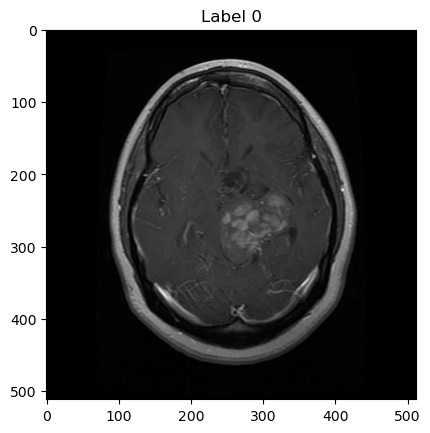

In [44]:
img_path = training_dataset.image_path[0]

img = Image.open(img_path)

label = training_dataset.labels[0]

plt.imshow(img)
plt.title(f"Label {label}")
plt.show()

In [64]:
# creating data loader

training_dataset = CustomBrainImageDataset( train_root_dir,transform=transform)


{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
total images 2870
total number of classes 4


In [65]:
dataset_size = len(training_dataset)
train_size= int(0.7*dataset_size)
val_size= int(0.15*dataset_size )
test_size = dataset_size-train_size-val_size

train_dataset, validation_dataset, test_dataset= random_split(training_dataset, [train_size,val_size,test_size], 
                                                             generator=torch.Generator().manual_seed(42))

In [66]:
train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
val_loader =DataLoader(validation_dataset,batch_size=32, shuffle=False)
test_loader =DataLoader(test_dataset,batch_size=32, shuffle=False)

In [67]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

torch.Size([32, 3, 224, 224])
torch.Size([32])
63
14
14


In [76]:
import torchvision.models as models

vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in vgg_model.features.parameters():
    param.requires_grad= False
    
# for name, param in vgg_model.named_parameters():
#     print(name, param.requires_grad)
num_features = vgg_model.classifier[6].in_features

vgg_model.classifier[6] = nn.Linear( num_features, 4)
print(vgg_model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=4, bias=True)
)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

vgg_model = vgg_model.to(device)

print(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.classifier.parameters(),lr=0.001, weight_decay=1e-4)

cuda


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    vgg_model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vgg_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.2084 Accuracy: 96.76%
Epoch [2/10] Loss: 0.2183 Accuracy: 96.12%
Epoch [3/10] Loss: 0.1564 Accuracy: 97.61%
Epoch [4/10] Loss: 0.0887 Accuracy: 98.16%
Epoch [5/10] Loss: 0.2527 Accuracy: 97.46%
Epoch [6/10] Loss: 0.4093 Accuracy: 96.17%
Epoch [7/10] Loss: 0.4993 Accuracy: 95.32%


KeyboardInterrupt: 